In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../..')

In [3]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler

from vimms_gym.env import DDAEnv
from vimms_gym.features import obs_to_dfs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (2000, 5000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

Initialise a new DDA environment that tracks the top most intense peaks.

In [11]:
max_peaks = 100
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan)

In [12]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  roi_length  \
 0      0.149947         0.0       0.0         0.0   
 1      0.149915         0.0       0.0         0.0   
 2      0.149320         0.0       0.0         0.0   
 3      0.149055         0.0       0.0         0.0   
 4      0.147133         0.0       0.0         0.0   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0       0.0         0.0   
 96     0.000000         0.0       0.0         0.0   
 97     0.000000         0.0       0.0         0.0   
 98     0.000000         0.0       0.0         0.0   
 99     0.000000         0.0       0.0         0.0   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [13]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [14]:
env.features

[mz=416.52951448836444 rt=200 intensity=997.5450318006875 (0.14994662549969937) roi=ROI with data points=1 fragmentations=0 mz (416.5295-416.5295) rt (200.0000-200.0000),
 mz=295.56697759250244 rt=200 intensity=996.1002994981257 (0.14991515353390827) roi=ROI with data points=1 fragmentations=0 mz (295.5670-295.5670) rt (200.0000-200.0000),
 mz=287.5847761039154 rt=200 intensity=969.1791472447654 (0.14932020306661037) roi=ROI with data points=1 fragmentations=0 mz (287.5848-287.5848) rt (200.0000-200.0000),
 mz=319.409130259922 rt=200 intensity=957.4322885318481 (0.14905540347893612) roi=ROI with data points=1 fragmentations=0 mz (319.4091-319.4091) rt (200.0000-200.0000),
 mz=458.44924909021825 rt=200 intensity=876.2945711164201 (0.14713250605644623) roi=ROI with data points=1 fragmentations=0 mz (458.4492-458.4492) rt (200.0000-200.0000),
 mz=560.4946410728238 rt=200 intensity=870.6005927532761 (0.1469909479256652) roi=ROI with data points=1 fragmentations=0 mz (560.4946-560.4946) rt 

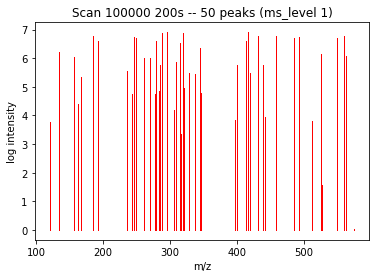

In [15]:
env.render()

Generate 10 ms1 scans

In [16]:
for i in range(10):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.432367         0.0       0.0       0.028   
 1      0.404979         0.0       0.0       0.024   
 2      0.327979         0.0       0.0       0.012   
 3      0.303562         0.0       0.0       0.020   
 4      0.276601         0.0       0.0       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0       0.0       0.000   
 96     0.000000         0.0       0.0       0.000   
 97     0.000000         0.0       0.0       0.000   
 98     0.000000         0.0       0.0       0.000   
 99     0.000000         0.0       0.0       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [17]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [18]:
env.features

[mz=595.8939871738346 rt=204.00000000000006 intensity=443960466.4132561 (0.43236721494908814) roi=ROI with data points=8 fragmentations=0 mz (595.8940-595.8940) rt (201.2000-204.0000),
 mz=267.77721175939325 rt=204.00000000000006 intensity=125768982.11902764 (0.4049786773036559) roi=ROI with data points=7 fragmentations=0 mz (267.7772-267.7772) rt (201.6000-204.0000),
 mz=387.8552166493663 rt=204.00000000000006 intensity=3627194.45140545 (0.3279785419216839) roi=ROI with data points=4 fragmentations=0 mz (387.8552-387.8552) rt (202.8000-204.0000),
 mz=539.5769881787196 rt=204.00000000000006 intensity=1178248.5506398575 (0.30356184571038064) roi=ROI with data points=6 fragmentations=0 mz (539.5770-539.5770) rt (202.0000-204.0000),
 mz=380.90198035569216 rt=204.00000000000006 intensity=340429.11479132646 (0.276601334775754) roi=ROI with data points=1 fragmentations=0 mz (380.9020-380.9020) rt (204.0000-204.0000),
 mz=288.4977224464327 rt=204.00000000000006 intensity=150611.06702138094 (0

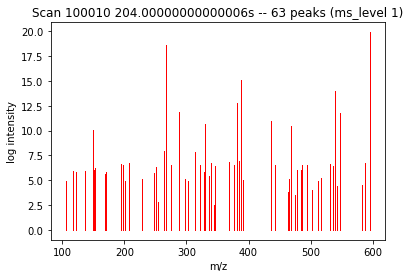

In [19]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [20]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.4864094722697086
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.432367         0.2  0.026667       0.028   
 1      0.404979         0.0  0.000000       0.024   
 2      0.327979         0.0  0.000000       0.012   
 3      0.303562         0.0  0.000000       0.020   
 4      0.276601         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0  0.000000       0.000   
 96     0.000000         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [21]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [22]:
env.features

[mz=595.8939871738346 rt=204.00000000000006 intensity=443960466.4132561 (0.43236721494908814) roi=ROI with data points=8 fragmentations=0 mz (595.8940-595.8940) rt (201.2000-204.0000),
 mz=267.77721175939325 rt=204.00000000000006 intensity=125768982.11902764 (0.4049786773036559) roi=ROI with data points=7 fragmentations=0 mz (267.7772-267.7772) rt (201.6000-204.0000),
 mz=387.8552166493663 rt=204.00000000000006 intensity=3627194.45140545 (0.3279785419216839) roi=ROI with data points=4 fragmentations=0 mz (387.8552-387.8552) rt (202.8000-204.0000),
 mz=539.5769881787196 rt=204.00000000000006 intensity=1178248.5506398575 (0.30356184571038064) roi=ROI with data points=6 fragmentations=0 mz (539.5770-539.5770) rt (202.0000-204.0000),
 mz=380.90198035569216 rt=204.00000000000006 intensity=340429.11479132646 (0.276601334775754) roi=ROI with data points=1 fragmentations=0 mz (380.9020-380.9020) rt (204.0000-204.0000),
 mz=288.4977224464327 rt=204.00000000000006 intensity=150611.06702138094 (0

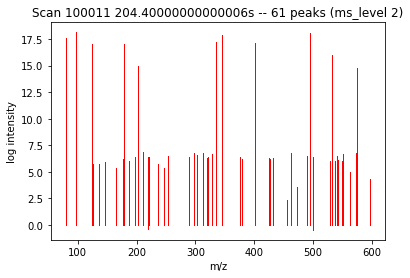

In [23]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [24]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.46525302822859405
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.432367         0.2      0.04       0.028   
 1      0.404979         0.2      0.04       0.024   
 2      0.327979         0.0      0.00       0.012   
 3      0.303562         0.0      0.00       0.020   
 4      0.276601         0.0      0.00       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0      0.00       0.000   
 96     0.000000         0.0      0.00       0.000   
 97     0.000000         0.0      0.00       0.000   
 98     0.000000         0.0      0.00       0.000   
 99     0.000000         0.0      0.00       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [25]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [26]:
env.features

[mz=595.8939871738346 rt=204.00000000000006 intensity=443960466.4132561 (0.43236721494908814) roi=ROI with data points=8 fragmentations=0 mz (595.8940-595.8940) rt (201.2000-204.0000),
 mz=267.77721175939325 rt=204.00000000000006 intensity=125768982.11902764 (0.4049786773036559) roi=ROI with data points=7 fragmentations=0 mz (267.7772-267.7772) rt (201.6000-204.0000),
 mz=387.8552166493663 rt=204.00000000000006 intensity=3627194.45140545 (0.3279785419216839) roi=ROI with data points=4 fragmentations=0 mz (387.8552-387.8552) rt (202.8000-204.0000),
 mz=539.5769881787196 rt=204.00000000000006 intensity=1178248.5506398575 (0.30356184571038064) roi=ROI with data points=6 fragmentations=0 mz (539.5770-539.5770) rt (202.0000-204.0000),
 mz=380.90198035569216 rt=204.00000000000006 intensity=340429.11479132646 (0.276601334775754) roi=ROI with data points=1 fragmentations=0 mz (380.9020-380.9020) rt (204.0000-204.0000),
 mz=288.4977224464327 rt=204.00000000000006 intensity=150611.06702138094 (0

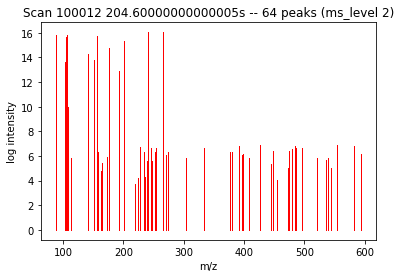

In [27]:
env.render()

Repeat targeting of the same precursor will end up producing 0 or negative reward.

In [28]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward 0.0019378795041569087
reward 0.0009559109176212714
reward 0.0009472250279833038
reward 0.0009385391383451818
reward 0.000929853248707137
reward 0.0009211673590690922
reward 0.0009124814694309704
reward 0.0009037955797929256
reward 0.0008951096901548808
reward 0.000886423800516836


In [29]:
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  roi_length  \
 0      0.432367         1.0  0.173333       0.028   
 1      0.404979         0.2  0.173333       0.024   
 2      0.327979         0.0  0.000000       0.012   
 3      0.303562         0.0  0.000000       0.020   
 4      0.276601         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0  0.000000       0.000   
 96     0.000000         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [30]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [31]:
env.features

[mz=595.8939871738346 rt=204.00000000000006 intensity=443960466.4132561 (0.43236721494908814) roi=ROI with data points=8 fragmentations=0 mz (595.8940-595.8940) rt (201.2000-204.0000),
 mz=267.77721175939325 rt=204.00000000000006 intensity=125768982.11902764 (0.4049786773036559) roi=ROI with data points=7 fragmentations=0 mz (267.7772-267.7772) rt (201.6000-204.0000),
 mz=387.8552166493663 rt=204.00000000000006 intensity=3627194.45140545 (0.3279785419216839) roi=ROI with data points=4 fragmentations=0 mz (387.8552-387.8552) rt (202.8000-204.0000),
 mz=539.5769881787196 rt=204.00000000000006 intensity=1178248.5506398575 (0.30356184571038064) roi=ROI with data points=6 fragmentations=0 mz (539.5770-539.5770) rt (202.0000-204.0000),
 mz=380.90198035569216 rt=204.00000000000006 intensity=340429.11479132646 (0.276601334775754) roi=ROI with data points=1 fragmentations=0 mz (380.9020-380.9020) rt (204.0000-204.0000),
 mz=288.4977224464327 rt=204.00000000000006 intensity=150611.06702138094 (0

Making an invalid move produces negative reward.

In [32]:
action = 90 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -1.0
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.432367         1.0  0.186667       0.028   
 1      0.404979         0.2  0.186667       0.024   
 2      0.327979         0.0  0.000000       0.012   
 3      0.303562         0.0  0.000000       0.020   
 4      0.276601         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0  0.000000       0.000   
 96     0.000000         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [33]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [34]:
env.features

[mz=595.8939871738346 rt=204.00000000000006 intensity=443960466.4132561 (0.43236721494908814) roi=ROI with data points=8 fragmentations=0 mz (595.8940-595.8940) rt (201.2000-204.0000),
 mz=267.77721175939325 rt=204.00000000000006 intensity=125768982.11902764 (0.4049786773036559) roi=ROI with data points=7 fragmentations=0 mz (267.7772-267.7772) rt (201.6000-204.0000),
 mz=387.8552166493663 rt=204.00000000000006 intensity=3627194.45140545 (0.3279785419216839) roi=ROI with data points=4 fragmentations=0 mz (387.8552-387.8552) rt (202.8000-204.0000),
 mz=539.5769881787196 rt=204.00000000000006 intensity=1178248.5506398575 (0.30356184571038064) roi=ROI with data points=6 fragmentations=0 mz (539.5770-539.5770) rt (202.0000-204.0000),
 mz=380.90198035569216 rt=204.00000000000006 intensity=340429.11479132646 (0.276601334775754) roi=ROI with data points=1 fragmentations=0 mz (380.9020-380.9020) rt (204.0000-204.0000),
 mz=288.4977224464327 rt=204.00000000000006 intensity=150611.06702138094 (0

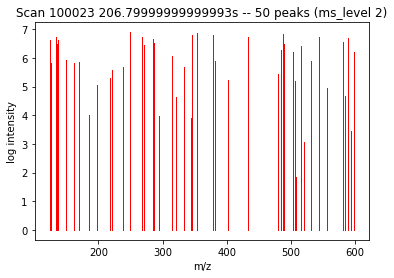

In [35]:
env.render()

Generate lots of MS1 scans

In [36]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.492789         0.0       0.0       0.324   
 1      0.489911         0.0       0.0       0.260   
 2      0.486734         0.0       0.0       0.152   
 3      0.485680         0.0       0.0       0.168   
 4      0.484204         0.0       0.0       0.372   
 ..          ...         ...       ...         ...   
 95     0.281845         0.0       0.0       0.124   
 96     0.281530         0.0       0.0       0.080   
 97     0.279208         0.0       0.0       0.180   
 98     0.276396         0.0       0.0       0.040   
 99     0.273962         0.0       0.0       0.352   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [37]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
      dtype=float32)

In [38]:
env.features

[mz=302.8982586050334 rt=246.60000000000048 intensity=7174169991.049531 (0.4927885831507312) roi=ROI with data points=82 fragmentations=0 mz (302.8983-302.8983) rt (214.2000-246.6000),
 mz=291.50161673485485 rt=246.60000000000048 intensity=6283777228.2313795 (0.4899110390040685) roi=ROI with data points=66 fragmentations=0 mz (291.5016-291.5016) rt (220.6000-246.6000),
 mz=334.216661124357 rt=246.60000000000048 intensity=5428602372.922257 (0.4867344016096771) roi=ROI with data points=39 fragmentations=0 mz (334.2167-334.2167) rt (231.4000-246.6000),
 mz=372.1333769832674 rt=246.60000000000048 intensity=5171421976.946697 (0.48568049883583164) roi=ROI with data points=43 fragmentations=0 mz (372.1334-372.1334) rt (229.8000-246.6000),
 mz=355.8968214604774 rt=246.60000000000048 intensity=4831582293.388603 (0.484204469050544) roi=ROI with data points=94 fragmentations=0 mz (355.8968-355.8968) rt (209.4000-246.6000),
 mz=332.21134564490416 rt=246.60000000000048 intensity=4239553582.7975645 

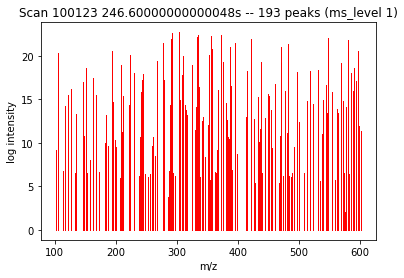

In [39]:
env.render()